## Интеллектуальный анализ данных

## Логистическая регрессия и SVM

#### План:
1. Логистическая регрессия
2. SVM.
3. Ирисы Фишера. Свойства логистической регрессии и SVM
4. Логистическая регрессия и SVM на менее приятных данных.
5. ROC-кривая. 
6. Бонус: вывод логистической регрессии через правдоподобие
---

### Логистическая регрессия

Напомним, что мы по-прежнему решаем задачу бинарной классификации, в которой целевая переменная $y$ принимает два значения: -1 и 1. Эту задачу можно решить при помощи линейного классификатора 

$$
f(x_i, w) = \mathrm{sign}\left(\langle x_i, w \rangle\right).
$$

Функция потерь для такой задачи – это сумма индикаторов того, что предсказание сделано неверно: 

$$Q(X, w) = \frac{1}{\ell}\sum_{i = 1}^{\ell}[y_i \ne \mathrm{sign}\left(\langle x_i, w \rangle\right)].$$

На лекциях мы обсуждали, что эту идею можно удобно записать через функцию отступа:

$$
Q(X, w) = \frac{1}{\ell}\sum_{i = 1}^{\ell}[y_i \langle x_i, w \rangle < 0].
$$

Такую функцию проблематично дифференцировать по $w$, потому что даже в местах, где градиент существует, он равен нулю. Вместо этого будем минимизировать некоторую функцию $\tilde{Q}(X, w)$, являющуюся верхней оценкой для $Q(X, w)$, и надеяться, что минимизация $\tilde{Q}(X, w)$ позволит достаточно хорошо минимизировать и $Q(X, w)$.

Логистическая регрессия предлагает использовать логистическую функцию потерь:

$$
\tilde{Q}(X, w) = \frac{1}{\ell}\sum_{i = 1}^{\ell}\log(1 + e^{-y_i \langle x_i, w \rangle}) \rightarrow \min_w.
$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

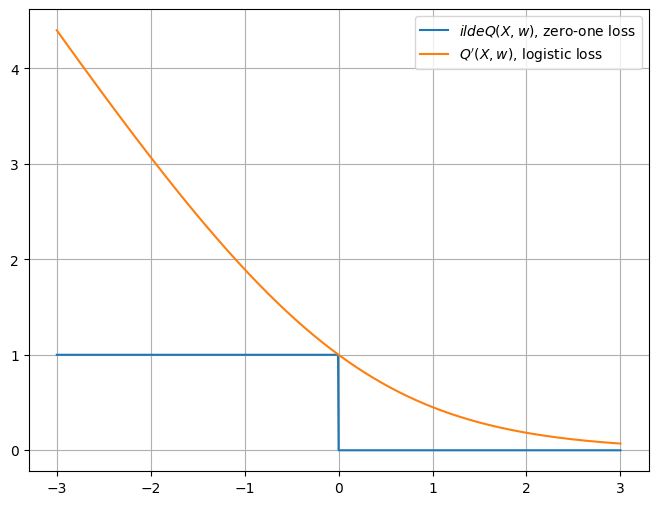

In [2]:
x = np.concatenate((np.linspace(-3, 0, 500), np.linspace(0, 3, 500))) # склеили два массива чисел 
# по 500 от -3 до 0 и от 0 до 3
np.random.seed(123) # зафиксировали случайность
y = np.ones(1000) # массив из 1000 единиц
w = np.ones(1000) # еще один
M = y * x * w # посчитали отступ

plt.figure(figsize = (8, 6)) # создали полотно
plt.plot(x * w, x < 0, label = "$\tilde{Q}(X, w)$, zero-one loss") # пороговая
plt.plot(M, np.log2(1 + np.exp(-M)), label = "$Q'(X, w)$, logistic loss") # логистическая
plt.grid() # добавили сетку на полотно
plt.legend(); # добавили легенду на полотно по label кривых

Для получения классической задачи логистической регрессии остаётся сделать один шаг и немного изменить постановку задачи. Предположим, что мы хотим решать задачу **мягкой** классификации, то есть предсказывать не метку класса, а вероятность того, что наблюдение принадлежит к классу. Понятно, что мы всегда можем перейти от мягкой классификации к жёсткой, выбрав порог принадлежности к положительному классу. 

**Задание 1.** Поясните, почему для решения задачи мягкой классификации классификатор $f(x_i, w) = \left(\langle x_i, w \rangle\right)$ – не лучший выбор. 

**Ответ** 

Полученное скалярное произведение необязательно будет лежать в отрезке $[0, 1]$. 

Мы можем решить названную проблему, подставив $\left(\langle x_i, w \rangle\right)$ в некоторую функцию, областью значений которой является промежуток от 0 до 1. В логистической регрессии такой функцией выступает **сигмоида**:

$$
\sigma(x) = \dfrac{e^x}{1 + e^x} = \dfrac{1}{1 + e^{-x}}.
$$

**Задание 2.** Сигмоида обаладет замечательнеым свойством, которое значительно упрощает вычисление градиентов при градиентном спуске:

$$
\sigma(x)'_x = \sigma(x)(1 - \sigma(x)). 
$$

Покажите, что это действительно так.

**Ответ**

$$
\sigma(x)' = \frac{e^x(1 + e^x) - e^{2x}}{(1 + e^x)^2} = \frac{e^x}{1 + e^x}\frac{1}{1 + e^x} = \sigma(x)(1-\sigma(x)).
$$

Путём хитрых математических преобразований можно показать, что при использовании сигмоиды (= при решении задачи мягкой классификации) $\tilde{Q}(X, w)$ можно записать в следующем виде:

$$
\tilde{Q}(X, w) = -\frac{1}{\ell} \sum_{i=1}^{\ell} [y_i = 1]\log\sigma(\langle x_i, w \rangle) + [y_i = -1]\log(1-\sigma(\langle x_i, w \rangle)
$$

Эта функция называется log-loss или кросс-энтропией между истинной целевой переменной и предсказанными вероятностями.

**А почему? А потому:**

$$
\tilde{Q}(X, w) = -\frac{1}{\ell} \sum_{i=1}^{\ell} [y_i = 1]\log\sigma(\langle x_i, w \rangle) + [y_i = -1]\log(1-\sigma(\langle x_i, w \rangle) =\\
$$
$$
=-\frac{1}{\ell} \sum_{i=1}^{\ell} [y_i = 1]\log\left(\frac{1}{1 + e^{-\langle x_i, w\rangle}}\right) + [y_i = -1](\log\left(1-\frac{1}{1 + e^{-\langle x_i, w\rangle}}\right)) =\\
$$
$$
=-\frac{1}{\ell} \sum_{i=1}^{\ell} [y_i = 1]\log\left(\frac{1}{1 + e^{-\langle x_i, w\rangle}}\right) + [y_i = -1](\log\left(\frac{1}{1 + e^{\langle x_i, w\rangle}}\right)) =\\
$$
$$
=\frac{1}{\ell} \sum_{i=1}^{\ell} [y_i = 1]\log(1 + e^{-\langle x_i, w \rangle}) + [y_i = -1]\log(1 + e^{\langle x_i, w \rangle}) =\\
$$
$$
=\frac{1}{\ell} \sum_{i=1}^{\ell}\log(1 + e^{-y_i\langle x_i, w\rangle}) = \tilde{Q}(X, w)
$$

Регуляризация вводится таким же образом, как это было в случае линейной регрессии. Например, функция потерь для $\ell$-$2$ регуляризации выглядит так:

$$
\tilde{Q}_{reg}(X, w) = \tilde{Q}(X, w) + \frac{1}{2}\lambda\|w\|^2_2.
$$

### Бонус для самых смелых: вывод логистической регрессии через правдоподобие

Перекодируем $y$ так, что её возможные значения – это 0 и 1. Теперь $y$ является случайной величиной из распределения Бернулли. Тогда сигмоида задаёт условную вероятность принадлежности $y$ к положительному классу:

$$
P(y_i = 1 | x_i, w) = \sigma(x_i, w).
$$

Будем искать оценку коэффициентов $w$ при помощи метода максимального правдоподобия.

$$
\mathcal{L} = \sigma(x_i, w)^{\sum_i y_i}(1 - \sigma(x_i, w))^{\sum_i 1 - y_i}
$$

Логарифмируем:

$$
\mathcal{l} = \sum_i y_i \log\sigma(x_i, w) + (1 - y_i)(1 - \log\sigma(x_i, w))
$$

Если теперь взять среднее, то мы получим log-loss, взятый со знаком минус. Таким образом, минимизация функции потерь в логистической регрессии эквивалентна  максимизации правдоподобия в задаче нахождения оценок $w$!

**Саммари по логистической регрессии:**

- Данные: $y_i \in \{-1, 1\}$, $X$

- Предсказания:

    - По умолчанию предсказывает вероятности:
    $$
    \hat{p}_i = \sigma(\langle x_i, w\rangle) = \frac{1}{1 + e^{-\langle x_i, w\rangle}}
    $$
    
    - Если хотим перейти к метке, то сравниваем вероятность с порогом $t$:
    
    $$
    \hat{y}_i = \begin{cases}
    1,&\text{ если } \hat{p}_i > t,\\
    -1,&\text{ иначе.}
    \end{cases}
    $$
    
- Обучение: 

$$
\tilde{Q}(X, w) = -\frac{1}{\ell} \sum_{i=1}^{\ell} [y_i = 1]\log\sigma(\langle x_i, w \rangle) + [y_i = -1]\log(1-\sigma(\langle x_i, w \rangle) \to \min_w
$$

### Метод опорных векторов (SVM)

Метод опорных векторов – математически строго обоснованный метод, идея которого состоит в максимизации ширины разделяющей полосы между классами. Так как для подробного вывода SVM требуется уверенное владение методами квадратичной оптимизации, мы разберём только идею и практическую реализацию метода. 

Мы по-прежнему решаем задачу бинарной классификации и используем классификатор $f(x_i, w) = \mathrm{sign}(\langle x_i, w\rangle)$. Предположим, что мы работаем с линейно разделимой выборкой. Определим отступ как минимальное расстояние от точек выборки до разделяющей поверхности классификатора:
$$
\rho(x_i, \langle x, w\rangle) =  \min_i\dfrac{|{\langle x_i, w\rangle|}}{\|w\|}
$$

Задача состоит в том, чтобы максимизировать этот отступ:

$$
\rho(x_i, \langle x, w\rangle) =  \min_i\dfrac{|{\langle x_i, w\rangle|}}{\|w\|} \to \max_w.
$$

Воспользуемся картинкой из Википедии, чтобы лучше понять эту идею:

[<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/72/SVM_margin.png/1920px-SVM_margin.png" alt="drawing" width="400"/>](https://en.wikipedia.org/wiki/Support-vector_machine#/media/File:SVM_margin.png)

Заметим, что при делении весов на положительное число ответы классификатора не меняются (веса просто пропорционально прошкалируются). Поделим все веса на 

$$\min_i |\langle x_i, w\rangle| > 0.$$ 

Тогда будет верно, что $\min_i |\langle x_i, w\rangle| = 1$, а значит отступ можно переписать как

$$
\rho(\langle x_i, w\rangle) = \frac{1}{\|w\|}.
$$

Получаем задачу SVM в линейно-разделимом случае:

$$
\begin{cases}
\|w\|^2 \to \min_{w}, \\
y_i(\langle x_i, w\rangle) \ge 1, \\
\end{cases}
$$

Если выборка не является линейно-разделимой, то нам придётся позволить линейному классификатору допускать ошибки на некоторых наблюдениях. Тогда задача превращается в поиск оптимального выбора между максимизацией ширины разделяющей полосы и ошибок классификации:

$$
\begin{cases}
\|w\|^2 + C \sum_{i = 1}^{\ell} \xi_i \to \min_{w, \xi_i}, \\
y_i(\langle x_i, w\rangle) \ge 1 - \xi_i, \\
\xi_i \ge 0
\end{cases}
$$

$C$ – параметр, который позволяет регулировать пропорции этого выбора. Чем больше $C$, тем больше штраф за неверную классификацию.

[<img src="https://miro.medium.com/max/1400/1*0vOVPBmYCkw-sUt77HtyGA.png" alt="drawing" width="800"/>](https://towardsdatascience.com/support-vector-machine-simply-explained-fee28eba5496)

Путём хитрых математических преобразований (объединив ограничения) можно показать, что итоговая функция потерь SVM выглядит следующим образом:

$$
Q(X, w) = C\sum_{i=1}^{l} \max\{0, 1 - y_i(\langle x_i, w\rangle)\} + \|w\|^2 \to \min_w
$$

### Ирисы Фишера. Свойства логистической регрессии и SVM

Рассмотрим свойства логистической регрессии и метода опорных векторов на примере классического набора данных ["Ирисы Фишера"](https://ru.wikipedia.org/wiki/Ирисы_Фишера). Этот набор состоит из 150 наблюдений, каждое из которых представляет собой четыре измерения: длина наружной доли околоцветника (`sepal length`), ширина наружной доли околоцветника (`sepal width`), длина внутренней доли околоцветника (`petal length`), ширина внутренней доли околоцветника (`petal width`). Каждое наблюдение относится к одному из трёх классов ириса: `setosa`, `versicolor` или `virginica`. Задача состоит в том, чтобы по измерениям предсказать класс цветка. 

[<img src="https://miro.medium.com/max/1000/1*Hh53mOF4Xy4eORjLilKOwA.png" alt="drawing" width="800"/>](https://miro.medium.com/max/1000/1*Hh53mOF4Xy4eORjLilKOwA.png)

In [3]:
# датасет загружженый в библиотеку sklearn
from sklearn.datasets import load_iris 
import seaborn as sns
import pandas as pd
import numpy as np


data = load_iris() # подгрузили датасет
X    = pd.DataFrame(data['data'], columns = data['feature_names']) # перевели его в dataframe 
y    = data['target'] # взяли целевую переменную
X.sample()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
72,6.3,2.5,4.9,1.5


**Задание 1.** Перейдём к задаче бинарной классификации: будем предсказывать принадлежность цветка к виду `versicolor` против принадлежности ко всем прочим видам. Перекодируйте зависимую переменную так, чтобы цветки вида `versicolor` имели метку 1, а прочих видов – метку -1. 

<Axes: ylabel='Count'>

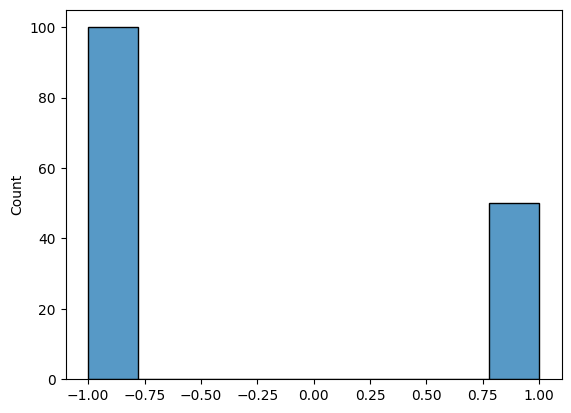

In [9]:
# 2 * (y == 1).astype(int) - 1
y = np.where(y == 1, 1, -1) # как можно переписать по другому?
sns.histplot(y)

In [5]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


**Задание 2**. Будем работать с двумя признаками: `sepal length (cm)` и `sepal width (cm)`. Отделите их в отдельную матрицу. Разделите выборку на обучающую и тестовую, долю тестовой выборки укажите равной 0.3. Отмасштабируйте выборки при помощи StandardScaler. Постройте диаграмму рассеяния по тренировочной выборке и убедитесь, что данные линейно не разделимы. 

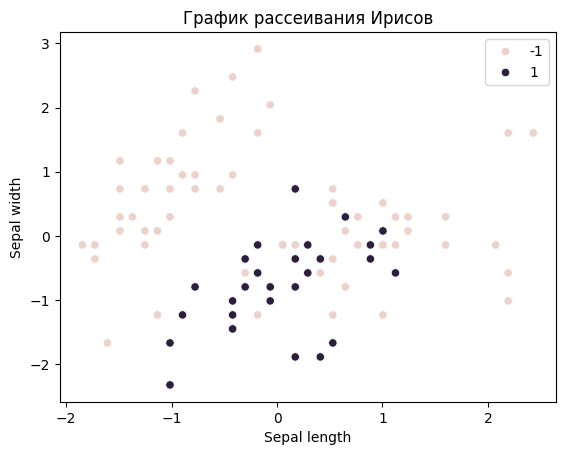

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
np.random.seed(123)

X = X[['sepal length (cm)', 'sepal width (cm)']]

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                   test_size=0.3,
                                                   random_state=5,
                                                   shuffle=True)

# Отмасштабируйте признаки
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

import seaborn as sns

sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train.reshape(-1))
plt.title('График рассеивания Ирисов')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

**Задание 3.** Обучите логистическую регрессию и **SVM с линейным ядром** на тренировочной выборке и убедитесь, что полученные оценки весов действительно различаются. Убедитесь, что `accuracy`, возможно, не подходит в качестве метрики для данной задачи и рассчитайте `f1-меру` на тестовой выборке. Какой алгорим показал более высокое качество?

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [12]:
lr  = LogisticRegression()
svm = SVC(kernel = 'linear')

# Обучите логистическую регрессию и SVM
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)

# Предсказать на тестовой выборке
y_pred_lr  = lr.predict(X_test)
y_pred_svm = svm.predict(X_test)

In [13]:
from sklearn.metrics import f1_score, accuracy_score

print(f'Accuracy score for LR:  {accuracy_score(y_test, y_pred_lr)}')
print(f'Accuracy score for SVM: {accuracy_score(y_test, y_pred_svm)}')

print(f'F1 score for LR:  {f1_score(y_test, y_pred_lr)}')
print(f'F1 score for SVM: {f1_score(y_test, y_pred_svm)}')

Accuracy score for LR:  0.6888888888888889
Accuracy score for SVM: 0.7333333333333333
F1 score for LR:  0.46153846153846156
F1 score for SVM: 0.45454545454545453


Теперь посмотрим, как различаются решающие поверхности алгоритмов. 

Код ниже построит решающие поверхности для классификаторов. Чтобы он заработал, нужно обязательно сделать `fit` для `lr` и `svm` выше.

In [15]:
!pip3 install mlxtend -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.
nglview 4.0 requires numpy<2.3, but you have numpy 2.4.4 which is incompatible.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  # sparse is always 2D. Implies a is 3D+
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  # sparse is always 2D. Implies a is 3D+
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  # sparse is always 2D. Implies a is 3D+


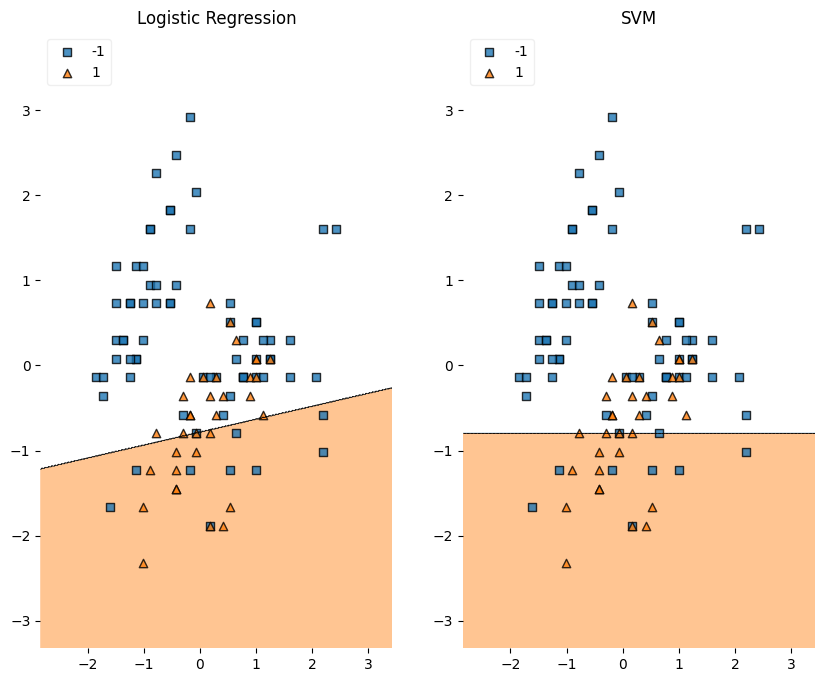

In [16]:
import itertools

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

from mlxtend.plotting import plot_decision_regions

gs = gridspec.GridSpec(1, 2)

fig = plt.figure(figsize=(10,8))

labels = ['Logistic Regression', 'SVM']
for clf, lab, grd in zip([lr, svm],
                         labels,
                         itertools.product([0, 1], repeat=2)):

    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X = np.array(X_train), y = np.array(y_train).reshape(-1), clf=clf, legend=2)
    plt.title(lab)

plt.show()

Теперь изучим свойства каждого классификатора по-отдельности. Начнём с логистической регрессии.

**Задание 3.** Обучите три различные логистические регрессии с разным параметром регуляризации $\alpha$ (обратите внимание, что в реализации `sklearn` $C = 1/\alpha$). Как изменяется разделяющая поверхность в зависимости от $\alpha$?

In [17]:
# Теория_LR = Ошибка в предсказаниях + alpha * Регуляризация
# Sklearn_LR = C * Ошибка в предсказаниях + Регуляризация

lr1 = LogisticRegression(C = 0.05)
lr2 = LogisticRegression(C = 0.1)
lr3 = LogisticRegression(C = 100)

In [18]:
for name, model in zip(['lr with C=0.05', 'lr with C=0.1', 'lr with C=100'], [lr1, lr2, lr3]):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f'Model {name} has accuracy {round(accuracy_score(y_pred, y_test), 2)} & f1 score {round(f1_score(y_pred, y_test), 2)}')

Model lr with C=0.05 has accuracy 0.67 & f1 score 0.12
Model lr with C=0.1 has accuracy 0.73 & f1 score 0.4
Model lr with C=100 has accuracy 0.69 & f1 score 0.46


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  # sparse is always 2D. Implies a is 3D+
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  # sparse is always 2D. Implies a is 3D+
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  # sparse is always 2D. Implies a is 3D+
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  # sparse is always 2D. Implies a is 3D+
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  # sparse is always 2D. Impli

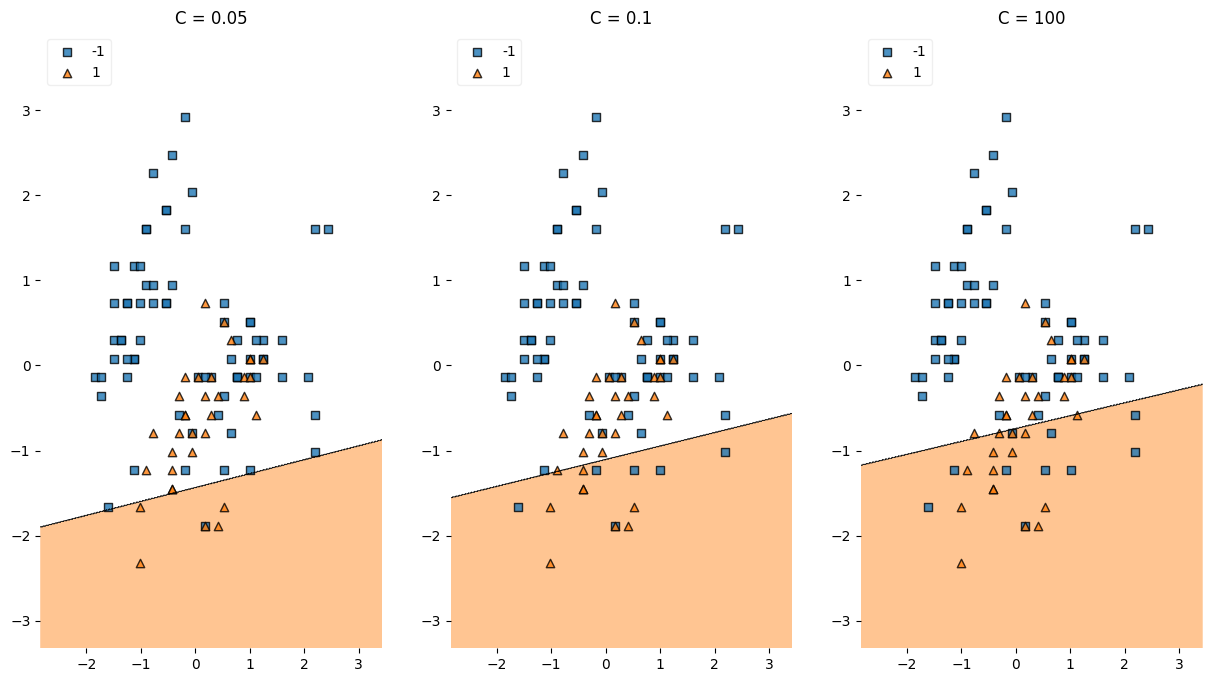

In [19]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
gs = gridspec.GridSpec(1, 3)

fig = plt.figure(figsize=(15,8))

labels = ['C = 0.05', 'C = 0.1', 'C = 100']
for clf, lab, grd in zip([lr1, lr2, lr3],
                         labels,
                         itertools.product([0, 1, 2], repeat=2)):
    clf.fit(X_train, y_train)
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X = np.array(X_train), y = np.array(y_train).reshape(-1), clf=clf, legend=2)
    plt.title(lab)

plt.show()
# Error 

**Задание 4.** Теперь посмотрим на решение задачи мягкой классификации. При помощи метода `predict_proba()` любой из обученных логистических регрессий сделайте предсказание вероятностей положительного класса.

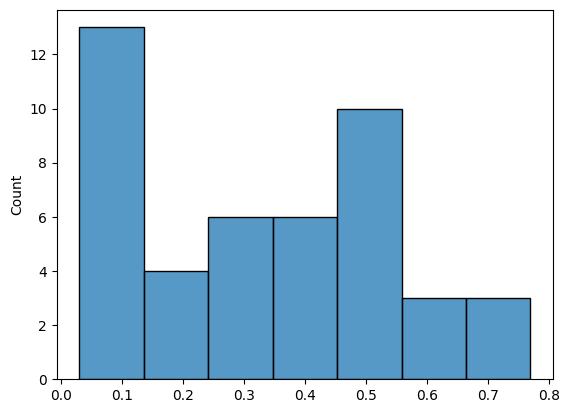

In [20]:
sns.histplot(lr3.predict_proba(X_test)[:, 1])
plt.show()

Перейдём к SVM.

**Задание 4.** Обучите три SVM с линейным ядром с разным параметром регуляризации $C$. Как изменяется разделяющая поверхность в зависимости от $C$?

In [21]:
svc1 = SVC(C = 0.08, kernel = 'linear')
svc2 = SVC(C = 1, kernel = 'linear')
svc3 = SVC(C = 10, kernel = 'linear')

In [22]:
for name, model in zip(['svm with C=0.08', 'svm with C=1', 'svm with C=10'], [svc1, svc2, svc3]):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f'Model {name} has accuracy {round(accuracy_score(y_pred, y_test), 2)} & f1 score {round(f1_score(y_pred, y_test), 2)}')

Model svm with C=0.08 has accuracy 0.67 & f1 score 0.12
Model svm with C=1 has accuracy 0.73 & f1 score 0.45
Model svm with C=10 has accuracy 0.71 & f1 score 0.48


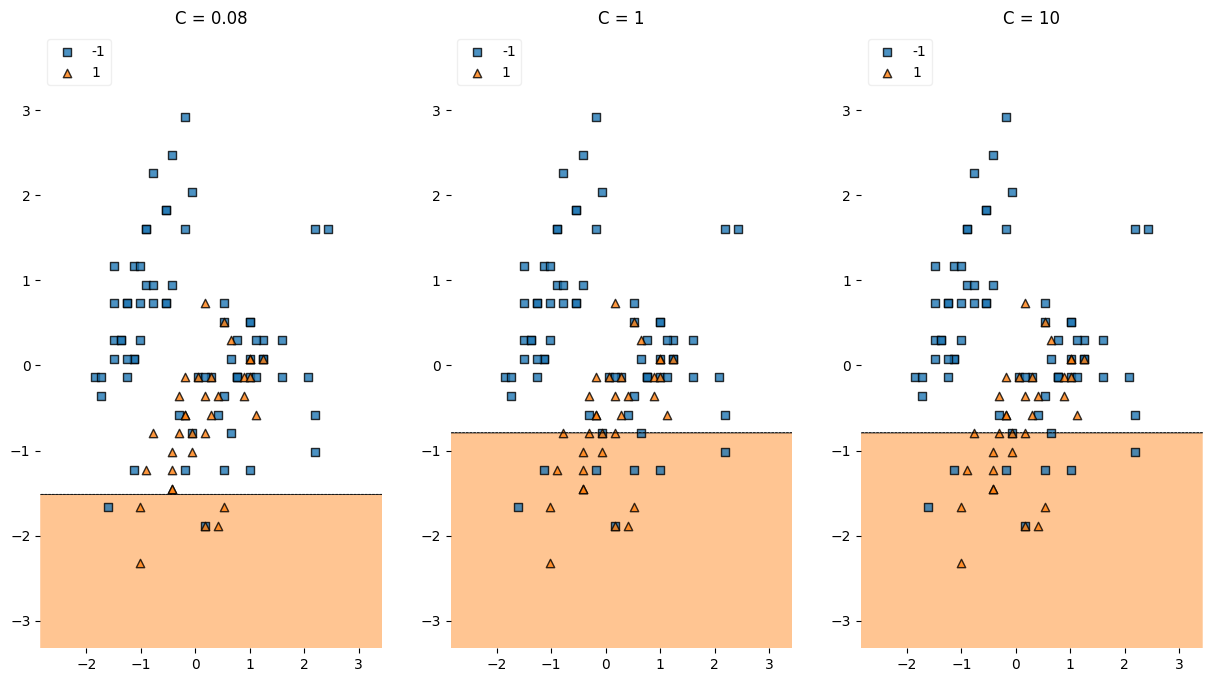

In [23]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
gs = gridspec.GridSpec(1, 3)

fig = plt.figure(figsize=(15,8))

labels = ['C = 0.08', 'C = 1', 'C = 10']
for clf, lab, grd in zip([svc1, svc2, svc3],
                         labels,
                         itertools.product([0, 1, 2], repeat=2)):
    clf.fit(X_train, y_train)
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X = X_train, y = np.array(y_train), clf=clf, legend=2)
    plt.title(lab)

plt.show()

# SVM = C * Ошибка в предсказаниях + Расстояние до классов от гиперплоскости

### Логистическая регрессия и SVM на менее приятных данных (если есть время)

Мы будем работать с [набором данных](https://www.kaggle.com/piyushgoyal443/red-wine-dataset?select=wineQualityReds.csv), содержащим информацию о характеристиках вина. Каждое наблюдение принадлежит к одному из 10 категорий качества вина, и наша задача заключается в том, что предсказать эту категорию. 

In [24]:
data = pd.read_csv('wineQualityReds.csv', index_col = 0)
data.head()

,fixed.acidity,volatile.acidity,citric.acid,residual.sugar,chlorides,free.sulfur.dioxide,total.sulfur.dioxide,density,pH,sulphates,alcohol,quality
1,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
2,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
3,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
4,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Как указано в описании набора, в нём нет пропущенных значений, и все переменные являются непрерывными. Целевая переменная – `quality`. 

**Задание 1.** Перейдём к задаче бинарной классификации и будем предсказывать только наиболее популярную категорию качества. Закодируйте столбец `quality` так, чтобы наиболее частая категория (это категория 5) получила метку 1, а все прочие категории – метку -1.

In [25]:
data['quality_binary'] = data['quality'].apply(lambda x: 1 if x == 5 else -1)

**Задание 2.** Разделите признаки и целевую переменную. Разделите выборку на тренировочную и тестовую, долю тестовой выборки укажите равной 0.3. При помощи `StandardScaler` отмасштабируйте тренировочную и тестовую выборки. 

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [34]:
X = data.drop(columns=['quality_binary', 'quality'], axis=1)
y = data.quality_binary
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn import preprocessing

normalizer = preprocessing.MinMaxScaler()
X_real_norm_np = normalizer.fit_transform(X_train)
X_real_norm_np = pd.DataFrame(data=X_real_norm_np)
X_real_norm_np.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.353982,0.068493,0.36,0.068493,0.086811,0.776119,0.250883,0.438326,0.574803,0.306748,0.400000
1,0.699115,0.232877,0.63,0.075342,0.098497,0.074627,0.031802,0.640969,0.196850,0.306748,0.276923
2,0.230088,0.287671,0.27,0.116438,0.120200,0.164179,0.254417,0.464758,0.511811,0.208589,0.400000
3,0.159292,0.376712,0.08,0.082192,0.055092,0.268657,0.148410,0.354626,0.590551,0.073620,0.461538
4,0.256637,0.315068,0.14,0.089041,0.108514,0.388060,0.190813,0.457416,0.425197,0.134969,0.215385


<Axes: ylabel='Count'>

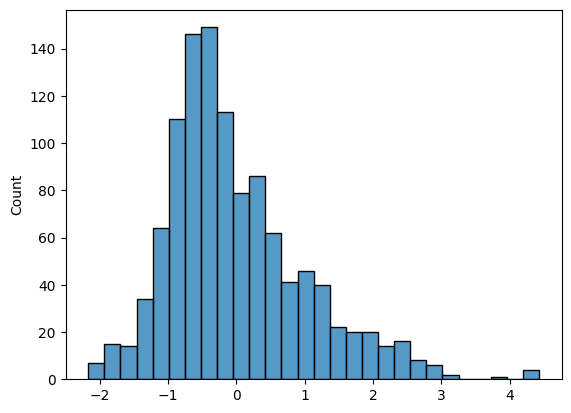

In [36]:
sns.histplot(X_train_scaled[:, 0])

<Axes: xlabel='0', ylabel='Count'>

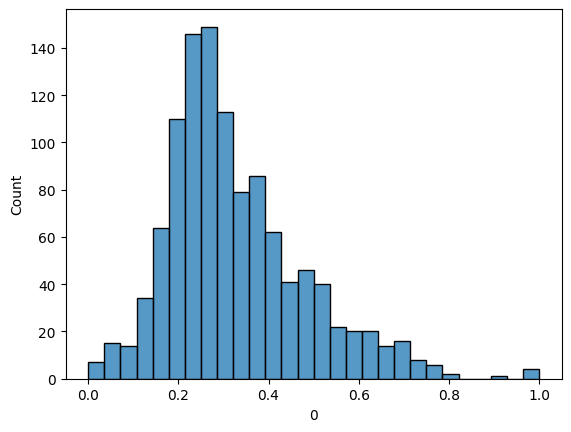

In [37]:
sns.histplot(X_real_norm_np.iloc[:, 0])

**Задание 3.** При помощи кросс-валидации (параметры выберите сами) подберите оптимальные значения коэффициентов регуляризации для логистической регрессии и SVM с линейным ядром. Обучите модели с этими параметрами. Убедитесь, что доля правильных ответов – не лучший вариант для нашей задачи и рассчитайте F-меру на тестовой выборке. Какой алгоритм показал себя лучше? 

 **Бонус для самых отважных:** качество работы SVM можно улучшить за счёт применения ядер, после чего разделяющая поверхность становится нелинейной.

In [38]:
from sklearn.model_selection import cross_validate

scores_lr = []
scores_svm = []

for c in np.arange(0.1, 10, 1):
    lr = LogisticRegression(C = c)
    svm = SVC(C = c)
    pass

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score

param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}  # Коэффициент регуляризации
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

f1_lr = f1_score(y_test, y_pred_lr)
print(f"LogReg: F1 = {f1_lr:.4f}, лучший параметр C = {grid_lr.best_params_['C']}")

LogReg: F1 = 0.6784, лучший параметр C = 10


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  weights, intercept = self.weight_intercept(coef)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  weights, intercept = self.weight_intercept(coef)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  weights, intercept = self.weight_intercept(coef)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow enco

In [40]:
param_grid_svm = {'C': [0.01, 0.1, 1, 10, 100]} 
grid_svm = GridSearchCV(SVC(kernel='linear'), param_grid_svm, cv=5, scoring='f1')
grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)

f1_svm = f1_score(y_test, y_pred_svm)
print(f"SVM (линейное ядро): F1 = {f1_svm:.4f}, лучший параметр C = {grid_svm.best_params_['C']}")

SVM (линейное ядро): F1 = 0.6825, лучший параметр C = 0.01


### ROC-кривая

Ранее мы узнали, что помимо accuracy в задачах классификации так же используются precision, recall и f-мера. Теперь пришло время познакомиться с ещё одной метрикой – ROC AUC.

Для начала вспомним, что мы работаем с матрицей ошибок:

|       | alg = 1          | alg = -1    |
|-------| -----------------|-------------|
|y = 1  |TP                |FN           |
|y = -1 |FP                | TN          |

Определим следующие величины:

$$
TPR \text{ (true positive rate, recall, sensitivity)} = \dfrac{TP}{TP + FN}
$$
– доля правильно предсказанных объектов положительного класса.

$$
FPR \text{ (false positive rate, 1 - specificity)} = \dfrac{FP}{FP + TN}
$$
– доля неправильно предсказанных объектов отрицательного класса.

Рассмотрим задачу мягкой классификации: мы предказываем вероятности принадлежности наблюдения к положительному и отрицательному классам. Тогда TPR и FPR будут зависеть от порога для вероятности, выше которого наблюдение будет отнесено к положительному классу. ROC-кривая строится в координатах $(FPR, TPR)$ и показывает комбинации TPR и FPR при всевозможных значениях порога. 

Для хорошего классификатора эта кривая является вогнутой, а для идеального классификатора она будет проходить через точку $(0, 1)$ (почему?).

[<img src="https://upload.wikimedia.org/wikipedia/commons/6/6b/Roccurves.png" alt="drawing" width="350"/>](https://ru.wikipedia.org/wiki/ROC-кривая)



**Задание 1.** Постройте ROC-кривую для следующей выборки.

In [41]:
y = [-1, 1, 1, -1, 1, 1] # True labels
p = [0.5, 0.1, 0.2, 0.9, 0.7, 0.1] # Predicted labels

**Решение:**
1. Упорядочим наблюдения по **убыванию** ответов алгоритма.

In [42]:
y = [-1, 1, -1, 1, 1, 1]
p = [0.9, 0.7, 0.5, 0.2, 0.1, 0.1]

2. Разобьём единичный квадрат на $(m, n)$ частей, где $m$ – число 1 в $y$, $n$ – число нулей. Стартуем из точки $(0, 0)$. Если значение $y$ равно 1, делаем шаг вверх, а если -1 – вправо. Понятно, что конечная точка нашего маршрута – точка $(1, 1)$.

**Важный момент:** если у нескольких объектов значения предсказаний равны, а $y$ – различны, то мы должны сделать ход "по диагонали". 

Если построить кривую по этому алгоритму, то получим:

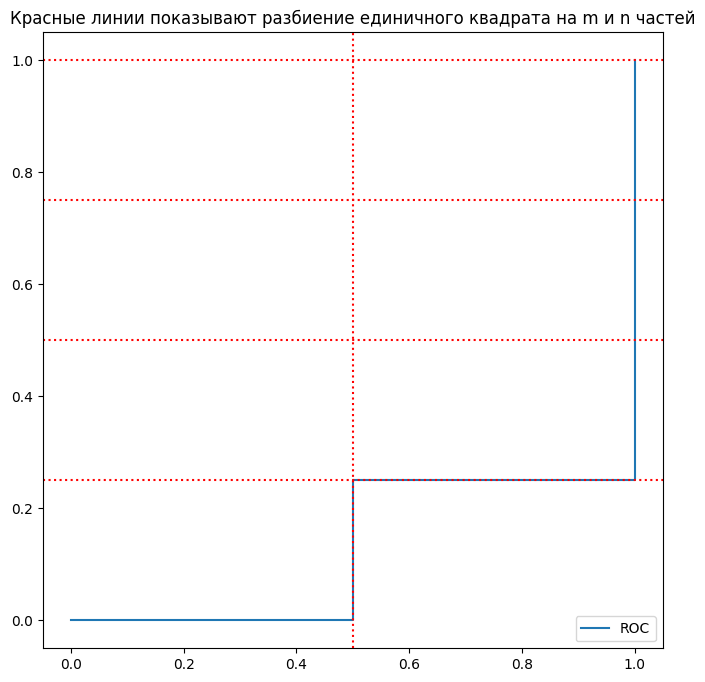

In [43]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y, p)

plt.figure(figsize = (8, 8))
plt.plot(fpr, tpr, label = 'ROC')
plt.axvline(0.5, linestyle = 'dotted', c = 'red')
plt.axhline(0.25, linestyle = 'dotted', c = 'red')
plt.axhline(0.5, linestyle = 'dotted', c = 'red')
plt.axhline(0.75, linestyle = 'dotted', c = 'red')
plt.axhline(1.0, linestyle = 'dotted', c = 'red')
plt.title('Красные линии показывают разбиение единичного квадрата на m и n частей')
plt.legend()

3. Полученная кривая и является ROC-кривой. 

**(Почему этот алгоритм имеет смысл?)**

**Пример с диагональным шагом.**

In [44]:
p = [0.5, 0.1, 0.2, 0.6, 0.2, 0.3, 0.0]
y = [-1,  -1,   -1, 1,    1,   1,   -1]

In [45]:
fpr, tpr, _ = roc_curve(y, p)

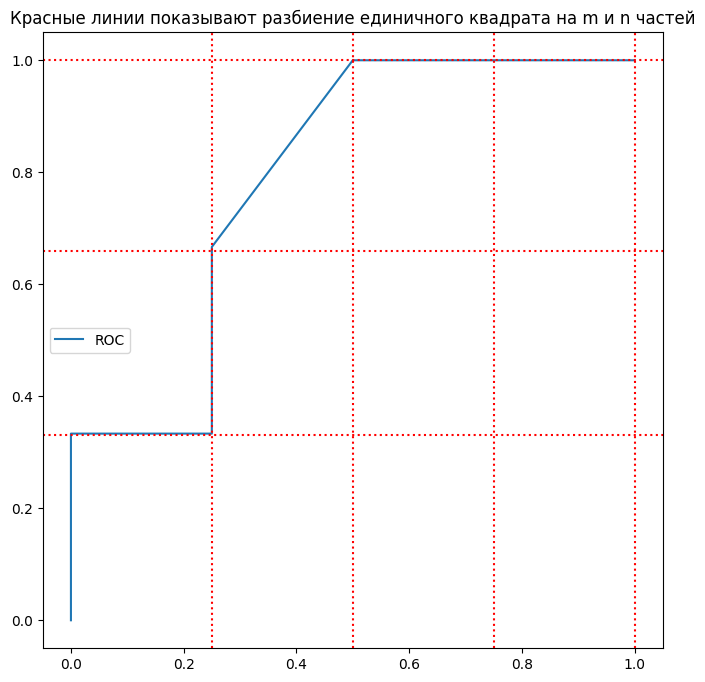

In [46]:
plt.figure(figsize = (8, 8))
plt.plot(fpr, tpr, label = 'ROC')
plt.axvline(0.25, linestyle = 'dotted', c = 'red')
plt.axvline(0.5, linestyle = 'dotted', c = 'red')
plt.axvline(0.75, linestyle = 'dotted', c = 'red')
plt.axvline(1.0, linestyle = 'dotted', c = 'red')
plt.axhline(0.33, linestyle = 'dotted', c = 'red')
plt.axhline(0.66, linestyle = 'dotted', c = 'red')
plt.axhline(1.0, linestyle = 'dotted', c = 'red')
plt.title('Красные линии показывают разбиение единичного квадрата на m и n частей')
plt.legend()

**Задание 2.** ROC AUC – площадь под ROC-кривой – равна доле пар наблюдений $(y = 1, y = -1)$, которые алгоритм верно упорядочил. Таким образом, чем больше ROC AUC, тем качественнее отработал классификатор. Вычислите ROC AUC для построенной ROC-кривой из первого примера. 

**Решение:**

In [47]:
0.25 * 0.5

0.125

**Задание 3.** Как выглядит ROC-кривая для случайного классификатора? 


**Задание 4.** Как по ROC-кривой выбрать порог для бинаризации?

В `sklearn` реализовано вычисление значений ROC-кривой и площади под ней. 

In [48]:
from sklearn.metrics import roc_curve, auc

**Важно:** в `roc_curve` передаются предсказанные вероятности!

**Задание 5.** Постройте ROC-кривую и рассчитайте площадь под ней для логистической регрессии на данных о вине. О чём говорит такая форма кривой?

In [49]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

# ...

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  weights, intercept = self.weight_intercept(coef)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  weights, intercept = self.weight_intercept(coef)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  weights, intercept = self.weight_intercept(coef)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow enco

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'
